#Problem Statement 1
## Part 1

In [42]:
# ========================================
# Part 1: Understanding Returns and Covariance Structure
# ========================================

# All imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

np.random.seed(42)

### Part a

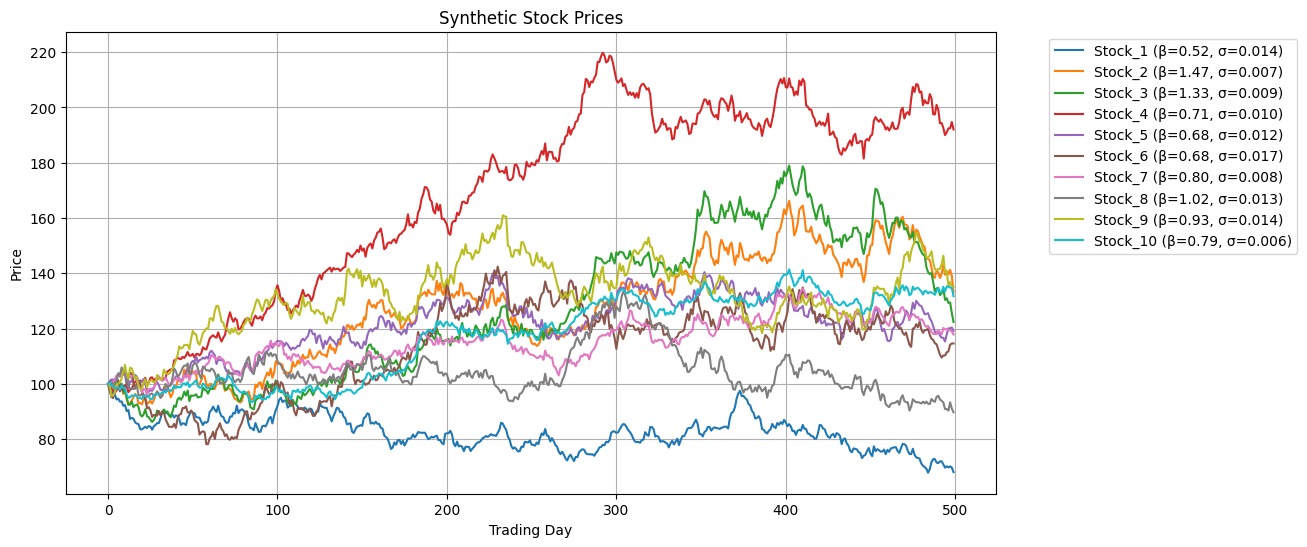

,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5,Stock_6,Stock_7,Stock_8,Stock_9,Stock_10
0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1,97.934694,100.636391,100.786630,99.354544,101.033869,97.516709,100.261987,98.896156,99.480375,100.363246
2,96.469326,99.527894,100.971323,98.366555,101.638091,95.309313,100.214723,100.152013,95.619944,99.473089
3,97.138520,99.006996,100.970142,97.575202,101.556699,94.886798,100.930177,100.221333,95.841086,99.049136
4,96.191620,97.881580,100.574733,96.762377,101.505026,97.861696,101.157403,99.237563,96.941204,98.387493


In [43]:
########################################
# (a) Generate synthetic stock prices
########################################
np.random.seed(42)  # to make random numbers reproducible
N_stocks = 10
N_days = 500

# Set parameters

P0 = 100

mu = np.random.uniform(
    0.0001,
    0.0005,
    N_stocks
)

beta = np.random.uniform(
    0.5,
    1.5,
    N_stocks
)

sigma = np.random.uniform(
    0.005,
    0.02,
    N_stocks
)

# Generate common factor
# f_t ~ N(0, 0.01)

f = np.random.normal(
    0,
    0.01,
    N_days
)

# Generate prices using the DGP
# P_i,t = P_i,t-1 * exp(mu_i + beta_i * f_t + eps_i,t)

prices = np.zeros(
    (N_days, N_stocks)
)

prices[0] = P0

for t in range(1, N_days):

    eps = np.random.normal(
        0,
        sigma
    )

    prices[t] = prices[t-1] * np.exp(
        mu + beta*f[t] + eps
    )

stock_names = [
    f"Stock_{i+1}"
    for i in range(N_stocks)
]

prices_df = pd.DataFrame(
    prices,
    columns=stock_names
)

# Plot all 10 price series

plt.figure(figsize=(12,6))

for i, stock in enumerate(prices_df.columns):
    plt.plot(
        prices_df.index,
        prices_df[stock],
        label=f"{stock} (β={beta[i]:.2f}, σ={sigma[i]:.3f})"
    )

plt.title("Synthetic Stock Prices")
plt.xlabel("Trading Day")
plt.ylabel("Price")
plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.grid(True)
plt.show()
prices_df.head()   # to ensure all stocks start from 100

### Observations

1. All stocks start from the same initial price (100), but their trajectories diverge over time due to differences in drift (μ), factor loadings (β), and idiosyncratic noise (σ).

2. Stock_2 (β = 1.47) and Stock_3 (β = 1.33) show stronger reactions to market movements and experience larger price swings compared to stocks with lower β values. This demonstrates that higher factor loadings increase sensitivity to the common market factor.

3. Stock_1 (β = 0.52) shows relatively weaker participation in market-wide movements and ends significantly lower than most other stocks, illustrating the effect of a smaller factor loading.

4. Despite having similar market exposure, stocks do not follow identical paths because each stock is affected by its own idiosyncratic noise term (epsilon_{i,t}).

5. The widening gap between the best-performing and worst-performing stocks over time highlights how small differences in μ, β, and σ accumulate through exponential compounding.

### Part b

In [44]:
########################################
# (b) Compute log returns
########################################

def compute_log_returns(prices):

    # returns shape:
    # (N_days-1, N_stocks)

    log_returns = np.log(
        prices[1:] / prices[:-1]
    )

    return log_returns


returns = compute_log_returns(prices)

returns_df = pd.DataFrame(
    returns,
    columns=stock_names
)

returns_df.head()
#print(f"Returns shape: {returns_df.shape}")

,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5,Stock_6,Stock_7,Stock_8,Stock_9,Stock_10
0,-0.020869,0.006344,0.007836,-0.006475,0.010286,-0.025146,0.002616,-0.011100,-0.005210,0.003626
1,-0.015076,-0.011076,0.001831,-0.009994,0.005963,-0.022896,-0.000472,0.012619,-0.039579,-0.008909
2,0.006913,-0.005247,-0.000012,-0.008077,-0.000801,-0.004443,0.007114,0.000692,0.002310,-0.004271
3,-0.009796,-0.011432,-0.003924,-0.008365,-0.000509,0.030871,0.002249,-0.009864,0.011413,-0.006702
4,-0.019004,0.020557,0.007521,0.009845,0.013010,0.040948,0.017634,0.016642,0.029120,0.002443


###Why returns not prices?
PCA requires stationary data. Prices are non-stationary — they trend upward
over time, meaning their mean and variance change with time. This violates the
assumptions of PCA, which treats the data as draws from a fixed distribution.

Log returns, defined as r_t = ln(P_t / P_{t-1}), are approximately stationary, they fluctuate around a constant mean with stable variance. PCA on returns
therefore captures genuine co-movement structure rather than spurious
correlations driven by shared price trends.

### Part c

In [45]:
########################################
# (c) Correlation and Covariance matrices
########################################

# Compute correlation matrix

corr_matrix = returns_df.corr()

# Compute covariance matrix

cov_matrix = returns_df.cov()

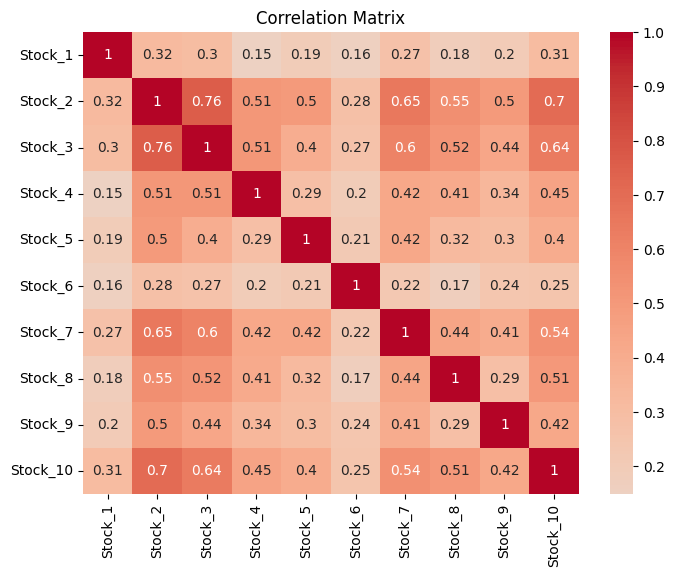

In [46]:
#correlation heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

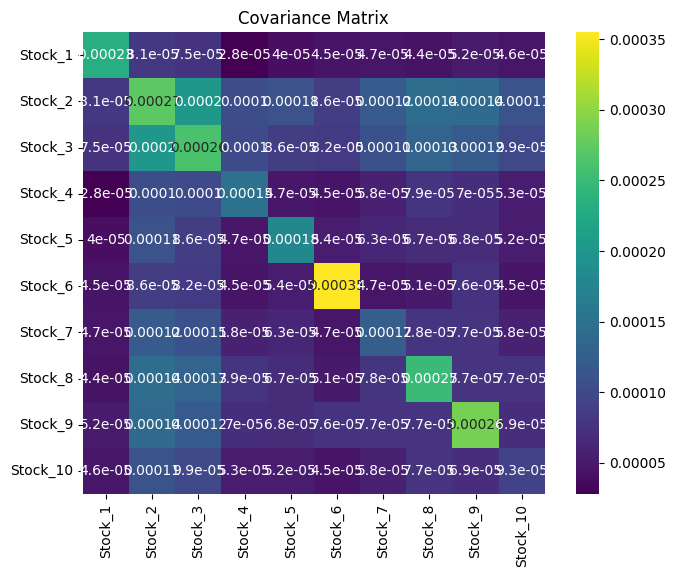

In [47]:
# covariance heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    cov_matrix,
    annot=True,
    cmap="viridis",
    square=True

)

plt.title("Covariance Matrix")
plt.show()

In [48]:
# Highest & Lowest Correlation Pair
corr_copy = corr_matrix.copy()

np.fill_diagonal(
    corr_copy.values,
    np.nan
)

max_pair = corr_copy.stack().idxmax()
max_value = corr_copy.stack().max()

min_pair = corr_copy.stack().idxmin()
min_value = corr_copy.stack().min()

print("Highest Correlation Pair:")
print(max_pair)
print("Correlation =", round(max_value,4))

print()

print("Lowest Correlation Pair:")
print(min_pair)
print("Correlation =", round(min_value,4))

Highest Correlation Pair:
('Stock_2', 'Stock_3')
Correlation = 0.7586

Lowest Correlation Pair:
('Stock_1', 'Stock_4')
Correlation = 0.1484


### Observations
1. All correlations are positive, which is expected — all stocks share the same common market factor f_t, so they tend to move together.
2. Stock_2 and Stock_3 have the highest correlation (0.76), suggesting they have similar factor loadings β, meaning the common factor affects them almost equally.
3. Stock_1 and Stock_4 have the lowest correlation (0.15), indicating their returns are driven more by idiosyncratic noise than by the shared factor.
4. The covariance matrix shows Stock_6 has the highest variance (brightest diagonal element), consistent with it having the highest σ drawn from U(0.005, 0.02).


### Part d

In [49]:
########################################
# (d) Standardize returns
########################################

def standardize_returns(returns):

    scaler = StandardScaler()

    standardized_returns = scaler.fit_transform(
        returns
    )

    return standardized_returns, scaler


standardized_returns, scaler = standardize_returns(
    returns
)

print("Mean of standardized returns:")
print(np.mean(
    standardized_returns,
    axis=0
))

print()

print("Standard deviation of standardized returns:")
print(np.std(
    standardized_returns,
    axis=0
))

Mean of standardized returns:
[ 1.11244792e-17 -4.00481251e-17 -4.00481251e-18 -7.34215628e-17
 -2.53638126e-17  4.35106193e-17  3.78232293e-17 -1.95790834e-17
  8.67709378e-18  3.02585834e-17]

Standard deviation of standardized returns:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


/tmp/ipykernel_1442/428394262.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


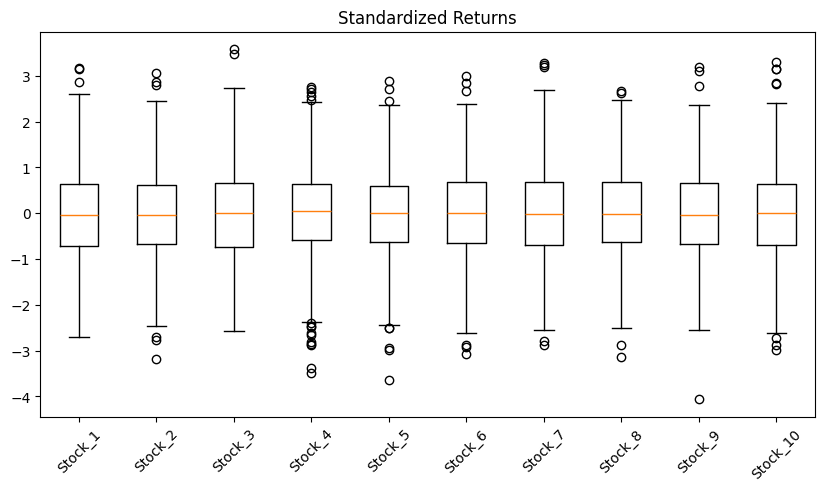

In [50]:
plt.figure(figsize=(10,5))

plt.boxplot(
    standardized_returns,
    labels=stock_names
)

plt.title(
    "Standardized Returns"
)

plt.xticks(rotation=45)

plt.show()

### Observations from Standardized Returns

1. The median return of each stock is close to zero, confirming successful mean centering.
2. The spreads of the boxplots are similar across all stocks, indicating that the returns have been scaled to unit variance.
3. A few extreme observations remain visible as outliers, showing that standardization rescales the data but does not remove unusual return events.


### Why standardization matters

Stocks can have significantly different volatilities.

Without standardization, highly volatile stocks dominate the covariance matrix and therefore dominate the principal components.

Standardization transforms each stock's return series to zero mean and unit variance, ensuring all stocks contribute equally to PCA.

If standardization is skipped:

- High-volatility stocks receive larger weights.
- PCA becomes volatility-driven.
- Important correlation structures may be obscured.

### Part e
#### Observations
1. The synthetic data successfully captures both systematic and idiosyncratic risk.
2. Price non-stationarity confirmed as raw prices drifted significantly from P₀ = 100 over 500 days due to compounding drift (μ) and factor exposure (β). This confirms why PCA must be applied to log returns rather than prices directly.
3. The correlation matrix reveals the common market factor through widespread positive correlations.
4. Standardization prevents high-volatility stocks from dominating the analysis.
5. The dataset resembles realistic financial markets where common factors drive asset co-movement while firm-specific noise introduces dispersion.


## Part 2

In [51]:
# ========================================
# Part 2: Understanding PCA and Eigendecomposition
# ========================================

from sklearn.decomposition import PCA

### Part 2 a

#### PCA function

In [52]:
########################################
# (a) PCA on standardized returns
########################################

def perform_pca(data, n_components=None):

    pca = PCA(n_components=n_components)

    pca.fit(data)

    eigenvalues = pca.explained_variance_

    eigenvectors = pca.components_

    explained_var_ratio = pca.explained_variance_ratio_

    return pca, eigenvalues, eigenvectors, explained_var_ratio


pca, eigenvalues, eigenvectors, explained_var_ratio = perform_pca(
    standardized_returns
)

#### Variance table

In [53]:
variance_table = pd.DataFrame({
    "PC": range(1, len(eigenvalues)+1),
    "Eigenvalue": eigenvalues,
    "Explained Variance Ratio": explained_var_ratio,
    "Cumulative Variance": np.cumsum(explained_var_ratio)
})

variance_table

,PC,Eigenvalue,Explained Variance Ratio,Cumulative Variance
0,1,4.657302,0.464797,0.464797
1,2,0.933417,0.093155,0.557951
2,3,0.867779,0.086604,0.644555
3,4,0.731315,0.072985,0.717540
4,5,0.703557,0.070215,0.787755
5,6,0.585750,0.058458,0.846213
6,7,0.525421,0.052437,0.898650
7,8,0.447737,0.044684,0.943334
8,9,0.351836,0.035113,0.978447
9,10,0.215966,0.021553,1.000000


#### Scree plot

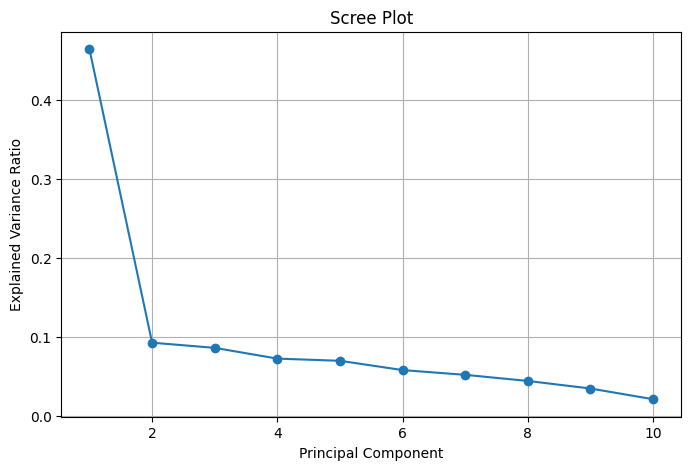

In [54]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained_var_ratio)+1),
    explained_var_ratio,
    marker='o'
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")

plt.grid(True)

plt.show()

#### Cumulative Variance Plot

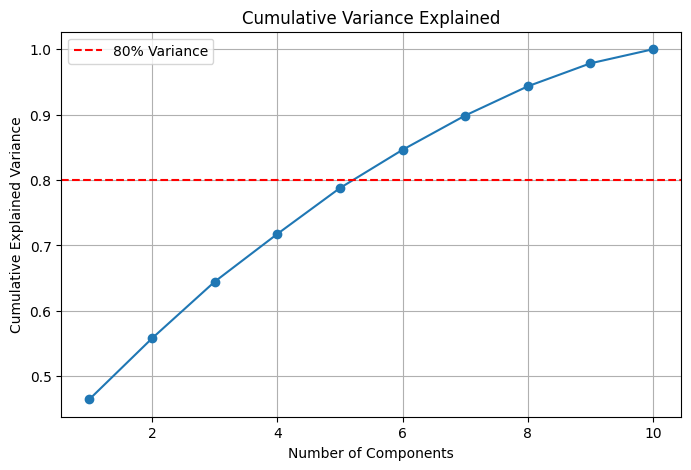

In [55]:
cum_var = np.cumsum(explained_var_ratio)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cum_var)+1),
    cum_var,
    marker='o'
)

plt.axhline(
    y=0.80,
    color='red',
    linestyle='--',
    label='80% Variance'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("Cumulative Variance Explained")

plt.legend()

plt.grid(True)

plt.show()

Components Needed to explain ≥ 80%

In [56]:
n_components_80 = np.argmax(
    cum_var >= 0.80
) + 1

print(
    f"Components required for >=80% variance = {n_components_80}"
)

Components required for >=80% variance = 6


#### Observations

1. The first principal component (PC1) explains approximately 46.48% of the total variance, making it the most important component in the dataset.

2. There is a sharp drop in explained variance from PC1 to PC2, indicating that a dominant common factor drives a large portion of stock return variation.

3. The scree plot shows a clear elbow from PC1 to PC2 (46.5% to 9.3%), suggesting diminishing returns from adding additional principal components.

4. The cumulative variance plot shows that 6 principal components are sufficient to explain more than 80% of the total variance (84.62%).

5. Since only 6 out of 10 components capture most of the information, the return matrix exhibits substantial dimensionality reduction potential.

6. The presence of a dominant first component is consistent with the synthetic data generation process, where all stocks are influenced by a common market factor.

Part 2 b

In [57]:
########################################
# (b) PCA on covariance matrix
########################################

pca_raw, eigenvalues_raw, eigenvectors_raw, explained_var_ratio_raw = perform_pca(
    returns
)

In [58]:
eigenvalue_comparison = pd.DataFrame({
    "PC": range(1,11),
    "Eigenvalue (Standardized)": eigenvalues,
    "Eigenvalue (Raw Returns)": eigenvalues_raw
})

eigenvalue_comparison

,PC,Eigenvalue (Standardized),Eigenvalue (Raw Returns)
0,1,4.657302,0.000986
1,2,0.933417,0.000306
2,3,0.867779,0.000205
3,4,0.731315,0.000196
4,5,0.703557,0.000137
5,6,0.585750,0.000123
6,7,0.525421,0.000092
7,8,0.447737,0.000063
8,9,0.351836,0.000058
9,10,0.215966,0.000038


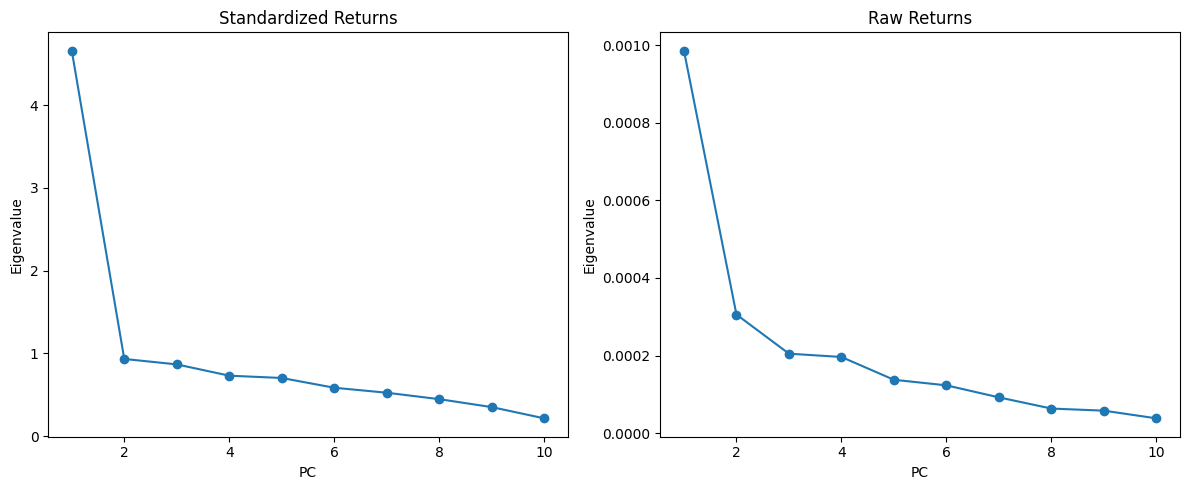

In [59]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(1,11), eigenvalues, marker='o')
plt.title("Standardized Returns")
plt.xlabel("PC")
plt.ylabel("Eigenvalue")

plt.subplot(1,2,2)
plt.plot(range(1,11), eigenvalues_raw, marker='o')
plt.title("Raw Returns")
plt.xlabel("PC")
plt.ylabel("Eigenvalue")

plt.tight_layout()
plt.show()

Variance ratios comparison

In [60]:
comparison = pd.DataFrame({
    "Standardized PCA": explained_var_ratio,
    "Raw Returns PCA": explained_var_ratio_raw
})

comparison

,Standardized PCA,Raw Returns PCA
0,0.464797,0.447426
1,0.093155,0.138693
2,0.086604,0.092889
3,0.072985,0.089012
4,0.070215,0.062327
5,0.058458,0.055832
6,0.052437,0.041755
7,0.044684,0.028663
8,0.035113,0.026192
9,0.021553,0.017211


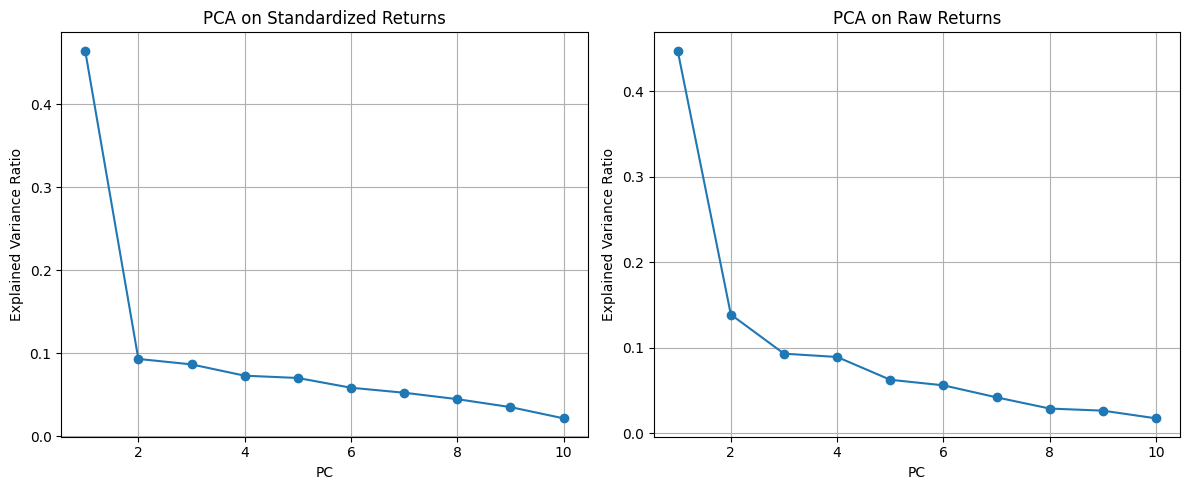

In [61]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(
    range(1,11),
    explained_var_ratio,
    marker='o'
)

plt.title("PCA on Standardized Returns")

plt.xlabel("PC")
plt.ylabel("Explained Variance Ratio")

plt.grid(True)

plt.subplot(1,2,2)

plt.plot(
    range(1,11),
    explained_var_ratio_raw,
    marker='o'
)

plt.title("PCA on Raw Returns")

plt.xlabel("PC")
plt.ylabel("Explained Variance Ratio")

plt.grid(True)

plt.tight_layout()

plt.show()

### Comparison of Eigenvalues and Explained Variance Ratios

1. The eigenvalues obtained from standardized returns are different from those obtained from raw returns because standardization rescales each stock to unit variance.

2. In the standardized case, the total variance is approximately equal to the number of stocks (10), whereas in the raw-return case the total variance depends on the original stock volatilities.

3. PCA on raw returns gives greater weight to high-volatility stocks, causing the leading eigenvalues to be more heavily influenced by those stocks.

4. Although the overall shape of the scree plots may be similar, the magnitudes of the eigenvalues and the explained variance ratios differ because the underlying variance structure has changed.

5. This demonstrates why standardization is often preferred when stocks have substantially different volatilities.

Part 2c
loadings function

In [62]:
# Interpret loadings

def plot_loadings(
    eigenvectors,
    component_idx,
    stock_names
):

    plt.figure(figsize=(10,5))

    plt.bar(
        stock_names,
        eigenvectors[component_idx]
    )

    plt.title(
        f"Loadings of PC{component_idx+1}"
    )

    plt.xticks(rotation=45)

    plt.grid(True)

    plt.show()

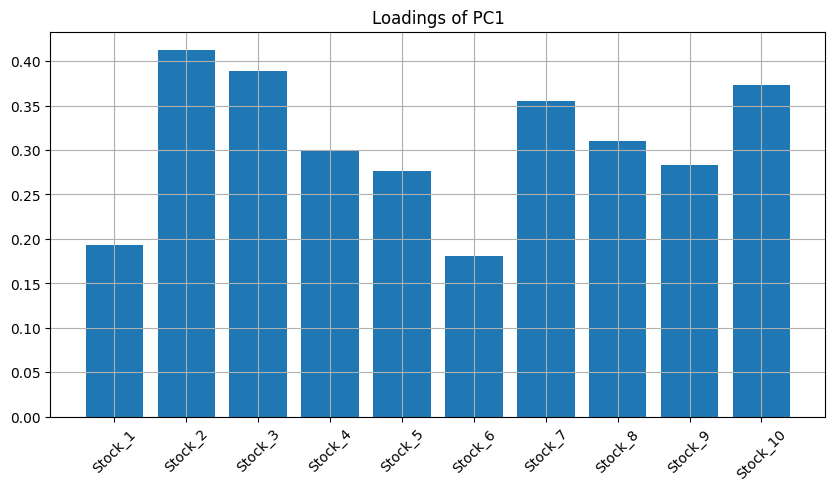

In [63]:
plot_loadings(
    eigenvectors,
    0,
    stock_names
)

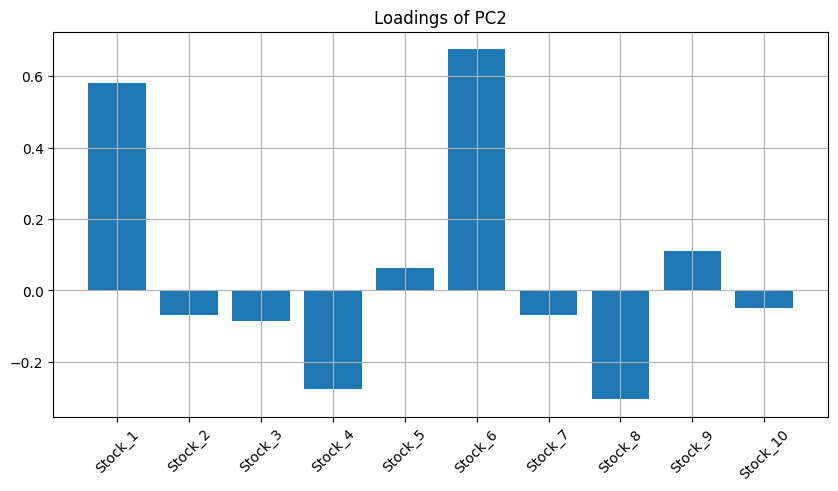

In [64]:
plot_loadings(
    eigenvectors,
    1,
    stock_names
)

In [65]:
loadings_df = pd.DataFrame(
    eigenvectors.T,
    columns=[f"PC{i+1}" for i in range(10)],
    index=stock_names
)

loadings_df.round(3)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
Stock_1,0.193,0.582,0.721,-0.154,-0.050,0.173,-0.196,0.098,0.006,-0.000
Stock_2,0.413,-0.070,0.041,0.036,0.021,-0.078,0.159,-0.180,0.225,0.841
Stock_3,0.389,-0.085,0.043,-0.124,-0.030,-0.048,0.283,-0.182,0.693,-0.477
Stock_4,0.300,-0.276,-0.182,-0.357,-0.035,0.791,-0.177,0.062,-0.110,0.004
Stock_5,0.276,0.062,-0.068,0.872,-0.124,0.242,-0.255,-0.040,0.041,-0.111
Stock_6,0.181,0.676,-0.629,-0.163,-0.285,-0.061,0.037,0.037,-0.021,0.013
Stock_7,0.355,-0.068,0.070,0.118,0.033,-0.054,0.571,0.646,-0.312,-0.080
Stock_8,0.310,-0.305,0.018,-0.160,-0.412,-0.460,-0.561,0.296,-0.007,-0.033
Stock_9,0.284,0.109,-0.175,-0.041,0.852,-0.172,-0.324,0.099,-0.008,-0.072
Stock_10,0.373,-0.051,0.090,-0.059,-0.044,-0.174,0.113,-0.635,-0.598,-0.202


### Observations
### Interpretation of Principal Component Loadings

#### PC1

1. All PC1 loadings are positive, indicating that all stocks move in the same direction when this component changes.
2. Stocks with larger PC1 loadings contribute more strongly to the common market movement.
3. This matches because all stocks were driven by the common factor:

#### PC2

1. PC2 contains both positive and negative loadings, indicating opposing behaviour among groups of stocks.

2. Stocks 1 and 6 have large positive loadings, whereas Stocks 4 and 8 have large negative loadings.

3. This suggests that PC2 captures relative performance differences rather than overall market movements.

4. Unlike PC1, PC2 represents a cross-sectional factor that separates stocks into groups with opposite sensitivities.

Part d

In [66]:
########################################
# (d) Compute and plot scores
########################################

def compute_scores(
    standardized_returns,
    eigenvectors
):

    scores = standardized_returns @ eigenvectors.T

    return scores


scores = compute_scores(
    standardized_returns,
    eigenvectors
)

print(scores.shape)

(499, 10)


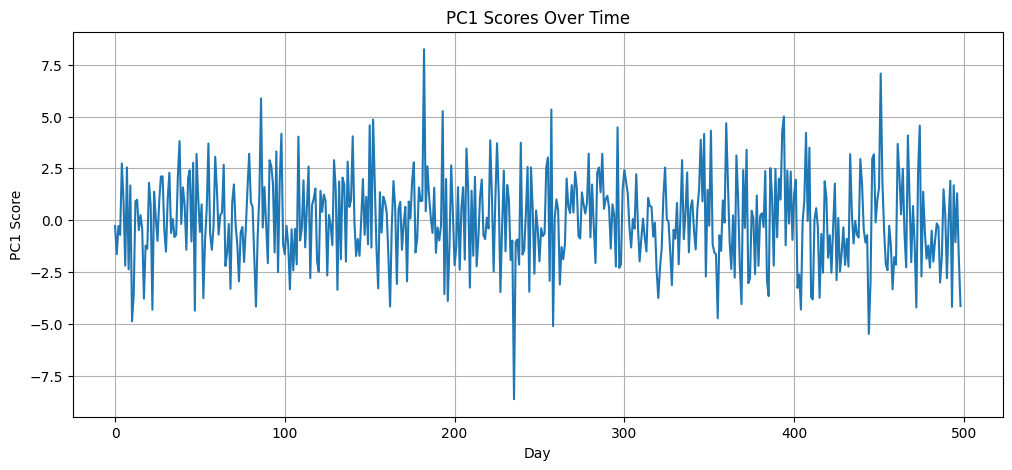

In [67]:
plt.figure(figsize=(12,5))

plt.plot(scores[:,0])

plt.title("PC1 Scores Over Time")

plt.xlabel("Day")

plt.ylabel("PC1 Score")

plt.grid(True)

plt.show()

In [68]:
market_return = returns_df.mean(axis=1)

corr = np.corrcoef(
    scores[:,0],
    market_return
)[0,1]

print(
    f"Correlation between PC1 and Market Return = {corr:.4f}"
)

Correlation between PC1 and Market Return = 0.9891


### Observations
### Interpretation of Principal Component Scores

1. The PC1 scores fluctuate around zero over time, which is expected because the returns were standardized before applying PCA.

2. Large positive PC1 scores correspond to periods when most stocks move together in a positive direction, while large negative scores correspond to periods of broad market declines.

3. The correlation between PC1 scores and the average market return is 0.9891, indicating an almost perfect relationship.

4. This extremely high correlation confirms that PC1 represents the common market factor driving the synthetic stock returns.


In [69]:
########################################
# (e) Disprove "loadings = scores"
########################################

print("Shape of PC1 Loadings:")
print(eigenvectors[0].shape)

print()

print("Shape of PC1 Scores:")
print(scores[:,0].shape)

Shape of PC1 Loadings:
(10,)

Shape of PC1 Scores:
(499,)


In [70]:
comparison_table = pd.DataFrame({
    "Quantity": ["Loadings", "Scores"],
    "Shape": [
        str(eigenvectors[0].shape),
        str(scores[:,0].shape)
    ],
    "Meaning": [
        "Contribution of each stock to PC1",
        "Value of PC1 over time"
    ]
})

comparison_table

,Quantity,Shape,Meaning
0,Loadings,"(10,)",Contribution of each stock to PC1
1,Scores,"(499,)",Value of PC1 over time


### Why Loadings and Scores Are Different

1. Loadings measure the contribution of each stock to a principal component.

2. Scores measure the value of that principal component at each point in time.

3. For PC1, the loadings vector contains one value for each stock and therefore has shape (10,).

4. The score series contains one value for each observation day and therefore has shape (499,).

5. Loadings provide a cross-sectional view of stock contributions, whereas scores provide a time-series view of factor behaviour.

### Part 2 f
### Overall Observations

1. PCA successfully reduced the dimensionality of the return data while retaining most of the information.

2. The first principal component (PC1) explains approximately 46.48% of the total variance, making it the dominant factor in the dataset.

3. Six principal components are sufficient to explain more than 80% of the total variance, indicating that the 10-dimensional return space can be represented using a much smaller number of factors.

4. PCA performed on standardized returns and raw returns produced similar scree plot shapes because the synthetic stocks have relatively similar volatilities. However, the eigenvalues differ in magnitude due to the effect of standardization.

5. All PC1 loadings are positive, indicating that PC1 represents a common market-wide factor that affects all stocks in the same direction.

6. PC2 contains both positive and negative loadings, suggesting that it captures relative performance differences between groups of stocks rather than overall market movements.

7. The correlation between PC1 scores and the average market return is 0.9891, providing strong evidence that PC1 corresponds to the underlying market factor used in the data generation process.

8. Loadings and scores serve different purposes: loadings describe how strongly each stock contributes to a principal component, whereas scores describe how that component evolves over time.

9. The results demonstrate that PCA is an effective tool for identifying common risk factors and reducing the complexity of financial datasets.


Part 3 a


In [71]:
########################################
# (a) Reconstruct returns using k components
########################################

def reconstruct(scores, loadings, k):

    X_hat = scores[:, :k] @ loadings[:k, :]

    return X_hat


def compute_msre(X_original, X_reconstructed):

    msre = np.mean(
        (X_original - X_reconstructed) ** 2
    )

    return msre

In [72]:
msre_values = []

for k in range(1, 11):

    X_hat = reconstruct(
        scores,
        eigenvectors,
        k
    )

    msre = compute_msre(
        standardized_returns,
        X_hat
    )

    msre_values.append(msre)

msre_df = pd.DataFrame({
    "Components": range(1,11),
    "MSRE": msre_values
})

msre_df

,Components,MSRE
0,1,5.352031e-01
1,2,4.420485e-01
2,3,3.554445e-01
3,4,2.824596e-01
4,5,2.122448e-01
5,6,1.537872e-01
6,7,1.013504e-01
7,8,5.666636e-02
8,9,2.155329e-02
9,10,3.834777e-31


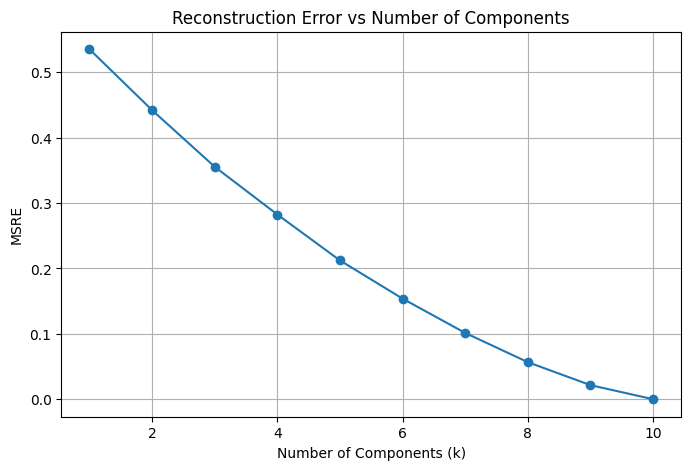

In [73]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    msre_values,
    marker='o'
)

plt.xlabel("Number of Components (k)")
plt.ylabel("MSRE")

plt.title("Reconstruction Error vs Number of Components")

plt.grid(True)

plt.show()

### Observations

1. The reconstruction error decreases steadily as the number of principal components increases.

2. Using only one principal component results in a relatively high MSRE (0.5352), indicating that a single factor cannot fully explain the variation in the stock returns.

3. The first three principal components reduce the MSRE to approximately 0.3554, showing that a significant amount of information is retained even after substantial dimensionality reduction.

4. The reduction in error becomes progressively smaller as additional components are added, demonstrating diminishing marginal benefits from each new principal component.

5. The results illustrate the trade-off between compression and accuracy: fewer components provide greater dimensionality reduction but introduce larger reconstruction errors.

Part 3b

In [74]:
########################################
# (b) Per-stock reconstruction error
########################################

k = 3

X_hat_3 = reconstruct(
    scores,
    eigenvectors,
    k
)

stock_errors = np.mean(
    (standardized_returns - X_hat_3) ** 2,
    axis=0
)

error_df = pd.DataFrame({
    "Stock": stock_names,
    "Reconstruction Error": stock_errors
})

error_df.sort_values(
    by="Reconstruction Error",
    ascending=False
)

,Stock,Reconstruction Error
4,Stock_5,0.638455
8,Stock_9,0.588675
3,Stock_4,0.481467
7,Stock_8,0.466063
6,Stock_7,0.405345
9,Stock_10,0.342836
2,Stock_3,0.287655
1,Stock_2,0.202765
5,Stock_6,0.080148
0,Stock_1,0.061036


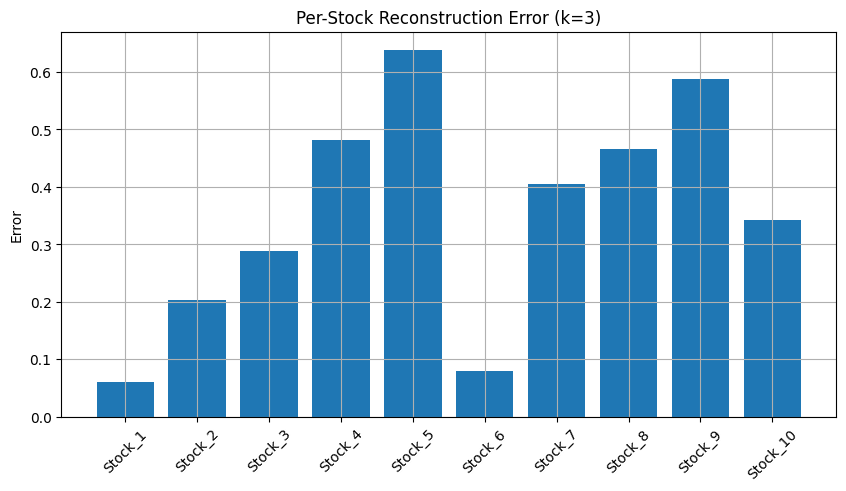

In [75]:
plt.figure(figsize=(10,5))

plt.bar(
    stock_names,
    stock_errors
)

plt.title(
    "Per-Stock Reconstruction Error (k=3)"
)

plt.ylabel("Error")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [76]:
worst_stock = stock_names[
    np.argmax(stock_errors)
]

worst_error = np.max(stock_errors)

print(
    f"Most idiosyncratic stock: {worst_stock}"
)

print(
    f"Reconstruction error: {worst_error:.4f}"
)

Most idiosyncratic stock: Stock_5
Reconstruction error: 0.6385


### Observations

1. Reconstruction errors vary significantly across stocks, indicating that the first three principal components do not explain all stocks equally well.

2. Stock_5 exhibits the highest reconstruction error (0.6385), suggesting that it is the most idiosyncratic.

3. Stocks with lower reconstruction errors are more strongly aligned with systematic market movements, whereas stocks with higher errors are influenced more heavily by idiosyncratic effects.

4. From a portfolio perspective, highly idiosyncratic stocks may contribute additional diversification benefits because their behaviour is less explained by common market factors.

Part 3c

In [77]:
########################################
# (c) Full reconstruction
########################################

X_hat_full = reconstruct(
    scores,
    eigenvectors,
    10
)

full_error = compute_msre(
    standardized_returns,
    X_hat_full
)

print(
    f"Full reconstruction MSRE = {full_error:.12f}"
)

Full reconstruction MSRE = 0.000000000000


### Why is the Error Approximately Zero?

1. PCA produces an orthonormal basis for the data space.

2. Using all 10 principal components preserves every direction of variation in the original dataset.

3. Therefore no information is discarded during reconstruction.

4. Any remaining error is due only to floating-point numerical precision.

Part 3 d

In [78]:
########################################
# (d) Correlation structure comparison
########################################

reconstructed_returns = reconstruct(
    scores,
    eigenvectors,
    3
)

corr_original = pd.DataFrame(
    standardized_returns,
    columns=stock_names
).corr()

corr_reconstructed = pd.DataFrame(
    reconstructed_returns,
    columns=stock_names
).corr()

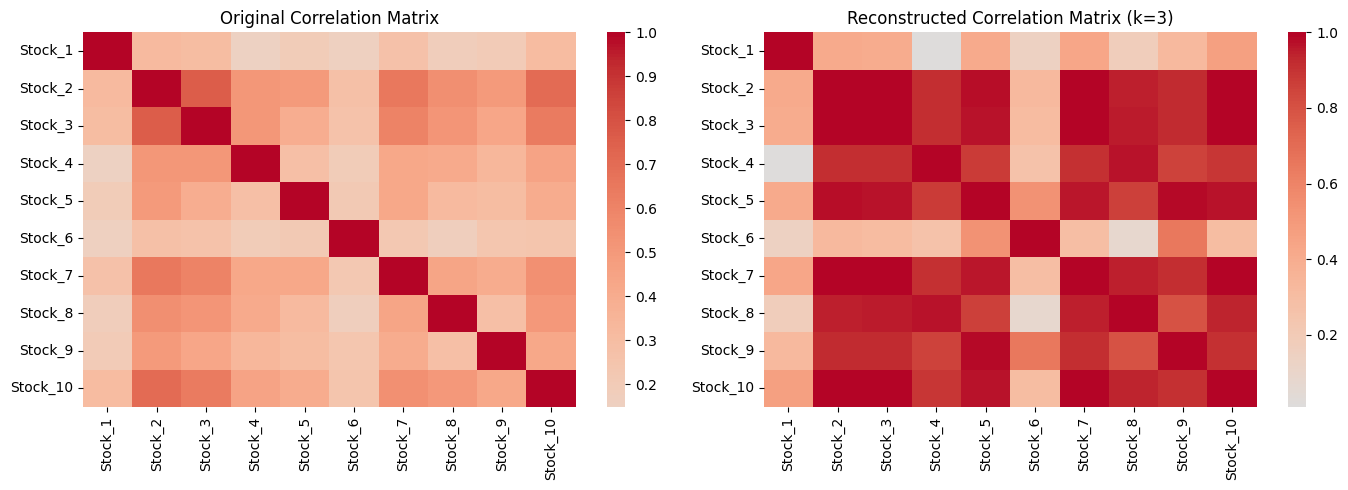

In [79]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

sns.heatmap(
    corr_original,
    cmap='coolwarm',
    center=0
)

plt.title(
    "Original Correlation Matrix"
)

plt.subplot(1,2,2)

sns.heatmap(
    corr_reconstructed,
    cmap='coolwarm',
    center=0
)

plt.title(
    "Reconstructed Correlation Matrix (k=3)"
)

plt.tight_layout()

plt.show()

In [80]:
corr_diff = np.abs(
    corr_original - corr_reconstructed
)

print(
    "Average Correlation Difference:",
    corr_diff.values.mean()
)

Average Correlation Difference: 0.3027631722310542


### Comparison of Original and Reconstructed Correlation Matrices

1. The reconstructed correlation matrix using only the first three principal components preserves the broad correlation structure of the original dataset.

2. Stocks that were positively correlated in the original matrix generally remain positively correlated after reconstruction.

3. The reconstructed correlations are noticeably stronger and more uniform than those in the original matrix.

4. Many correlation values move closer to 1 in the reconstructed matrix because PCA reconstruction using only a few components retains common systematic factors while filtering out stock-specific noise.

5. The original matrix contains both systematic and idiosyncratic effects, whereas the reconstructed matrix mainly reflects the dominant common factors captured by the first three principal components.


### Part 3e
### Observations

1. PCA provides an effective method for dimensionality reduction by representing the original return matrix using a smaller number of principal components.

2. The reconstruction error decreases monotonically as additional principal components are included, confirming that more information is retained as the dimensionality increases.

3. When all ten principal components are used, the reconstruction error becomes effectively zero, demonstrating that PCA preserves all information when the complete basis is retained.

4. The reconstructed correlation matrix preserves the major relationships among stocks but removes a portion of the idiosyncratic noise, resulting in stronger and more uniform correlations.

5. The average correlation difference of approximately 0.303 indicates that some information is lost during compression; however, the most important market structure remains intact.

6. Overall, PCA successfully captures the dominant market factors while filtering out a significant portion of stock-specific noise, making it a useful tool for financial modeling and risk analysis.

# Problem Statement 1: Part 4  
## Understanding Information Leakage in Unsupervised Learning

**PCA is unsupervised, but it can still leak future information if we fit it using test-period data.** We compare two workflows:

1. **Correct workflow:** Fit PCA only on the training period, then project the test period onto those training eigenvectors.
2. **Leaky workflow:** Fit PCA on the full dataset, including the test period, and then evaluate on the test period.

The leaky workflow is invalid because the PCA loadings and centering mean have already seen the test-period covariance structure.

In [1]:
# ========================================
# Part 4: Understanding Information Leakage in Unsupervised Learning
# ========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Markdown

np.random.seed(42)

try:
    standardized_returns
    print("Using existing standardized_returns from earlier notebook cells.")
except NameError:
    print("standardized_returns was not found, so fallback synthetic data is being generated.")

    N_stocks = 10
    N_days = 500
    P0 = 100

    mu = np.random.uniform(0.0001, 0.0005, N_stocks)
    beta = np.random.uniform(0.5, 1.5, N_stocks)
    sigma = np.random.uniform(0.005, 0.02, N_stocks)

    # Common factor and idiosyncratic shocks.
    f_t = np.random.normal(0, np.sqrt(0.01), N_days - 1)
    eps = np.random.normal(0, sigma, size=(N_days - 1, N_stocks))

    prices = np.zeros((N_days, N_stocks))
    prices[0, :] = P0

    for t in range(1, N_days):
        log_growth = mu + beta * f_t[t - 1] + eps[t - 1, :]
        prices[t, :] = prices[t - 1, :] * np.exp(log_growth)

    returns = np.log(prices[1:, :] / prices[:-1, :])
    standardized_returns = StandardScaler().fit_transform(returns)

# Convert to numpy array in case the earlier notebook stored it as a DataFrame.
standardized_returns = np.asarray(standardized_returns, dtype=float)

# Basic validation checks to avoid silent mistakes.
if standardized_returns.ndim != 2:
    raise ValueError("standardized_returns must be a 2D matrix of shape (days, stocks).")

if standardized_returns.shape[0] < 351:
    raise ValueError("standardized_returns must have at least 351 rows so that train/test split works.")

if np.isnan(standardized_returns).any():
    raise ValueError("standardized_returns contains NaN values. Please clean the earlier return matrix first.")

n_obs, n_assets = standardized_returns.shape
stock_names = [f"Stock {i+1}" for i in range(n_assets)]

print("standardized_returns shape:", standardized_returns.shape)
print("Number of observations:", n_obs)
print("Number of stocks/assets:", n_assets)

standardized_returns was not found, so fallback synthetic data is being generated.
standardized_returns shape: (499, 10)
Number of observations: 499
Number of stocks/assets: 10


---

## Part 4(a): Temporal train/test split and PCA on train only

We split the standardized return matrix chronologically:

- **Train set:** first 350 return observations
- **Test set:** all remaining observations, which should be 149 rows if the original price series had 500 days and therefore 499 log-return observations

The split must be temporal, not random. In finance, random splitting mixes future observations into the training set and gives an unrealistic estimate of model performance.

We then fit PCA only on the training set. The resulting eigenvectors are the only factor directions that would have been known at the end of the training period.

In [2]:
########################################
# (a) Temporal train/test split + PCA on train only
########################################

train_returns = standardized_returns[:350, :]
test_returns = standardized_returns[350:, :]

print("Train shape:", train_returns.shape)
print("Test shape :", test_returns.shape)

# Fit PCA on training data only.
# sklearn PCA automatically subtracts the training mean before fitting.
pca_train = PCA()
pca_train.fit(train_returns)

# Eigenvectors/loadings are stored as rows in sklearn: components_[pc_index, asset_index].
train_loadings = pca_train.components_
train_eigenvalues = pca_train.explained_variance_
train_explained_var_ratio = pca_train.explained_variance_ratio_
train_mean = pca_train.mean_

# Table of all components.
train_pca_summary = pd.DataFrame({
    "Component": np.arange(1, n_assets + 1),
    "Train eigenvalue": train_eigenvalues,
    "Train explained variance ratio": train_explained_var_ratio,
    "Train cumulative explained variance": np.cumsum(train_explained_var_ratio)
})

display(train_pca_summary)

# Display first 3 loading vectors in table form.
loading_table = pd.DataFrame(
    train_loadings[:3, :].T,
    index=stock_names,
    columns=["PC1 loading", "PC2 loading", "PC3 loading"]
)

display(loading_table)

Train shape: (350, 10)
Test shape : (149, 10)


,Component,Train eigenvalue,Train explained variance ratio,Train cumulative explained variance
0,1,9.212805,0.976621,0.976621
1,2,0.076666,0.008127,0.984749
2,3,0.049384,0.005235,0.989984
3,4,0.024360,0.002582,0.992566
4,5,0.021593,0.002289,0.994855
5,6,0.017253,0.001829,0.996684
6,7,0.014638,0.001552,0.998236
7,8,0.008500,0.000901,0.999137
8,9,0.005047,0.000535,0.999672
9,10,0.003098,0.000328,1.000000


,PC1 loading,PC2 loading,PC3 loading
Stock 1,0.310884,0.945110,0.089204
Stock 2,0.318971,-0.091395,-0.062485
Stock 3,0.317775,-0.078839,-0.043342
Stock 4,0.315458,-0.073556,-0.253905
Stock 5,0.317594,-0.081121,-0.296291
Stock 6,0.309236,-0.188756,0.896689
Stock 7,0.318884,-0.116451,-0.033145
Stock 8,0.316285,-0.074388,-0.051757
Stock 9,0.318339,-0.122539,-0.140951
Stock 10,0.318683,-0.102314,-0.079424


### Explanation for Part 4(a)

The PCA model above is the **honest training-period factor model**. It has only seen the first 350 observations.

The columns in the summary table mean:

- **Eigenvalue:** absolute variance captured by that principal component inside the training period.
- **Explained variance ratio:** fraction of training variance captured by that component.
- **Cumulative explained variance:** total variance captured by the first `k` components.

The loading table gives the asset weights inside the first few principal components. These loadings are the factor directions that will be used to project the test data in the next section.

---

## Part 4(b): Project the test data onto the training eigenvectors

For the correct out-of-sample procedure, the test data must be transformed using only training-period information.

That means:

1. Center test returns using the **training mean** learned by `pca_train`.
2. Project the centered test data onto the **training eigenvectors**.
3. Reconstruct the test data using only the first `k` components.
4. Compute explained variance using:

$$
EV_{\text{test}}(k)
=
1 -
\frac{\left\lVert X_{\text{test}} - \widehat{X}_{\text{test},k} \right\rVert_F^2}
{\left\lVert X_{\text{test}} \right\rVert_F^2}
$$

Here, $\left\lVert \cdot \right\rVert_F$ is the Frobenius norm. Intuitively, this formula asks: **how much of the test-period variation can the train-fitted PCA subspace explain?**


In [3]:
########################################
# (b) Project test data onto TRAIN eigenvectors
########################################

def compute_explained_variance_oos(test_data, train_loadings, k, train_mean):
    """
    Compute out-of-sample explained variance for test_data using PCA loadings
    learned only from the training period.
    """

    # Center test data using training mean only.
    # Using test_data.mean(axis=0) would leak test statistics.
    X_test_centered = test_data - train_mean

    # Select first k eigenvectors.
    V_k = train_loadings[:k, :]      # shape: (k, n_assets)

    # Project test observations onto training PCs.
    scores_test = X_test_centered @ V_k.T     # shape: (n_test, k)

    # Reconstruct centered test observations using the selected PCs.
    reconstructed_test = scores_test @ V_k    # shape: (n_test, n_assets)

    # Residual = what the selected PCA subspace fails to explain.
    residual_test = X_test_centered - reconstructed_test

    # Explained variance = 1 - residual variance / total variance.
    total_variance = np.sum(X_test_centered ** 2)
    residual_variance = np.sum(residual_test ** 2)
    explained_var_ratio_test = 1 - residual_variance / total_variance

    return explained_var_ratio_test, reconstructed_test, residual_test

# Compare train vs clean out-of-sample test explained variance for k = 1, 2, 3.
clean_rows = []
for k in [1, 2, 3]:
    ev_test_clean, _, residual_clean = compute_explained_variance_oos(
        test_data=test_returns,
        train_loadings=train_loadings,
        k=k,
        train_mean=train_mean
    )

    clean_rows.append({
        "k": k,
        "Train cumulative EV": np.sum(train_explained_var_ratio[:k]),
        "Clean test EV using train PCs": ev_test_clean,
        "Drop: train EV - clean test EV": np.sum(train_explained_var_ratio[:k]) - ev_test_clean,
        "Clean residual variance share": 1 - ev_test_clean
    })

clean_ev_df = pd.DataFrame(clean_rows)
display(clean_ev_df)

,k,Train cumulative EV,Clean test EV using train PCs,Drop: train EV - clean test EV,Clean residual variance share
0,1,0.976621,0.980686,-0.004065,0.019314
1,2,0.984749,0.987204,-0.002456,0.012796
2,3,0.989984,0.991780,-0.001796,0.008220


### Explanation for Part 4(b)

The clean test explained variance will usually be lower than the training explained variance. That drop is normal because PCA was optimized to explain the training covariance structure, not the future/test covariance structure.

Financially, this means that the factor model learned from the past does not perfectly explain future returns. The unexplained part is out-of-sample residual risk. If correlations, volatilities, or factor loadings change between the train and test periods, the drop becomes larger.

---

## Part 4(c): Leaky PCA fitted on the full dataset

Now we intentionally perform the wrong procedure:

1. Fit PCA on the **entire dataset**, which includes both train and test periods.
2. Use the full-data eigenvectors to reconstruct only the test data.
3. Compare the test explained variance from this leaky method with the clean method.

This is information leakage because the PCA loadings are influenced by the test period. Even though PCA has no labels or target variable, it still learns from the test-period covariance structure.

In [4]:
########################################
# (c) LEAKY approach: PCA on full data
########################################

# Fit PCA on all observations: train + test.
# This is the invalid/leaky step.
pca_full = PCA()
pca_full.fit(standardized_returns)

full_loadings = pca_full.components_
full_mean = pca_full.mean_
full_explained_var_ratio = pca_full.explained_variance_ratio_
full_eigenvalues = pca_full.explained_variance_

def compute_explained_variance_with_given_pca(test_data, pca_model, k):
    """
    Compute explained variance of test_data using an already-fitted PCA model.
    This function is used for the leaky full-data PCA model.
    """

    X_test_centered = test_data - pca_model.mean_
    V_k = pca_model.components_[:k, :]
    scores_test = X_test_centered @ V_k.T
    reconstructed_test = scores_test @ V_k
    residual_test = X_test_centered - reconstructed_test

    total_variance = np.sum(X_test_centered ** 2)
    residual_variance = np.sum(residual_test ** 2)
    explained_var_ratio = 1 - residual_variance / total_variance

    return explained_var_ratio, reconstructed_test, residual_test

# Compare clean and leaky test explained variance for k = 1, 2, 3.
leakage_rows = []
for k in [1, 2, 3]:
    ev_test_clean, _, _ = compute_explained_variance_oos(
        test_data=test_returns,
        train_loadings=train_loadings,
        k=k,
        train_mean=train_mean
    )

    ev_test_leaky, _, _ = compute_explained_variance_with_given_pca(
        test_data=test_returns,
        pca_model=pca_full,
        k=k
    )

    leakage_rows.append({
        "k": k,
        "Train cumulative EV (train PCA)": np.sum(train_explained_var_ratio[:k]),
        "Full-data cumulative EV (leaky PCA)": np.sum(full_explained_var_ratio[:k]),
        "Clean test EV using train PCs": ev_test_clean,
        "Leaky test EV using full-data PCs": ev_test_leaky,
        "Leakage gap: leaky - clean": ev_test_leaky - ev_test_clean,
        "Clean residual variance share": 1 - ev_test_clean,
        "Leaky residual variance share": 1 - ev_test_leaky
    })

leakage_df = pd.DataFrame(leakage_rows)
display(leakage_df)

,k,Train cumulative EV (train PCA),Full-data cumulative EV (leaky PCA),Clean test EV using train PCs,Leaky test EV using full-data PCs,Leakage gap: leaky - clean,Clean residual variance share,Leaky residual variance share
0,1,0.976621,0.978025,0.980686,0.980784,0.000098,0.019314,0.019216
1,2,0.984749,0.985620,0.987204,0.987382,0.000177,0.012796,0.012618
2,3,0.989984,0.990637,0.991780,0.991986,0.000206,0.008220,0.008014


### Explanation for Part 4(c)

The leaky method is invalid because it lets the PCA model see the full dataset before evaluation. This changes both:

- the **mean vector** used for centering, and
- the **eigenvectors/loadings** used as factor directions.

As a result, the leaky PCA basis is partially adapted to the test period. This often makes the test explained variance look better than it should. In practical terms, it can make a model appear more stable and more predictive than it really is.

The phrase **"PCA is unsupervised"** does not remove leakage. Leakage is not only about labels. Any use of future/test-period data to choose model parameters is leakage.

---

## Visual comparison: clean vs leaky explained variance

The next plots compare:

- training cumulative explained variance,
- clean test explained variance using train-only PCA,
- leaky test explained variance using full-data PCA,
- and the leakage gap.


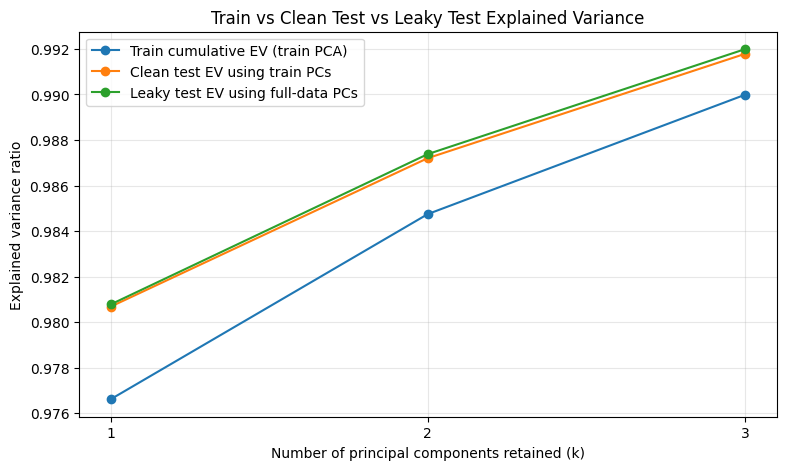

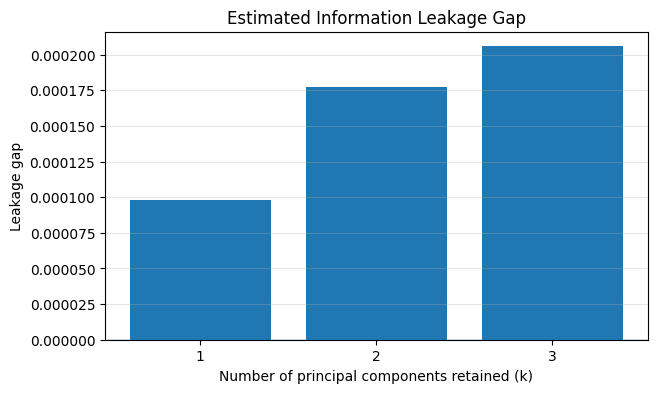

In [5]:
# Visual comparison for k = 1, 2, 3.
plot_df = leakage_df.set_index("k")[[
    "Train cumulative EV (train PCA)",
    "Clean test EV using train PCs",
    "Leaky test EV using full-data PCs"
]]

plt.figure(figsize=(9, 5))
for col in plot_df.columns:
    plt.plot(plot_df.index, plot_df[col], marker="o", label=col)

plt.xlabel("Number of principal components retained (k)")
plt.ylabel("Explained variance ratio")
plt.title("Train vs Clean Test vs Leaky Test Explained Variance")
plt.xticks([1, 2, 3])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(leakage_df["k"], leakage_df["Leakage gap: leaky - clean"])
plt.axhline(0, linewidth=1)
plt.xlabel("Number of principal components retained (k)")
plt.ylabel("Leakage gap")
plt.title("Estimated Information Leakage Gap")
plt.xticks([1, 2, 3])
plt.grid(True, axis="y", alpha=0.3)
plt.show()

---

## Part 4(d): Quantify the leakage gap

The leakage gap is:

$$
\mathrm{Leakage\ Gap}(k)
=
EV_{\text{test, leaky}}(k)
-
EV_{\text{test, clean}}(k)
$$

A positive gap means that fitting PCA on the full dataset made test performance look better than the honest out-of-sample procedure.

The gap is expected to be largest when the test period has a different covariance/correlation structure from the training period, especially during regime changes. It is expected to be smallest when the train and test periods are generated by almost the same covariance structure.


In [6]:
########################################
# (d) Quantify the leakage gap
########################################

# Extract the k=1,2,3 gaps clearly.
gap_table = leakage_df[[
    "k",
    "Clean test EV using train PCs",
    "Leaky test EV using full-data PCs",
    "Leakage gap: leaky - clean",
    "Clean residual variance share",
    "Leaky residual variance share"
]].copy()

display(gap_table)

# Create an automatic markdown-style summary using the actual numbers from the run.
summary_lines = []
for _, row in gap_table.iterrows():
    summary_lines.append(
        f"- For k = {int(row['k'])}, clean test EV = {row['Clean test EV using train PCs']:.4f}, "
        f"leaky test EV = {row['Leaky test EV using full-data PCs']:.4f}, "
        f"gap = {row['Leakage gap: leaky - clean']:.4f}."
    )

display(Markdown("### Numerical leakage summary from this run\n" + "\n".join(summary_lines)))

,k,Clean test EV using train PCs,Leaky test EV using full-data PCs,Leakage gap: leaky - clean,Clean residual variance share,Leaky residual variance share
0,1,0.980686,0.980784,0.000098,0.019314,0.019216
1,2,0.987204,0.987382,0.000177,0.012796,0.012618
2,3,0.991780,0.991986,0.000206,0.008220,0.008014


### Numerical leakage summary from this run
- For k = 1, clean test EV = 0.9807, leaky test EV = 0.9808, gap = 0.0001.
- For k = 2, clean test EV = 0.9872, leaky test EV = 0.9874, gap = 0.0002.
- For k = 3, clean test EV = 0.9918, leaky test EV = 0.9920, gap = 0.0002.

### Explanation for Part 4(d)

The clean residual variance share is the honest estimate of how much test-period risk is left unexplained after using the PCA factors learned from the training period.

The leaky residual variance share is usually smaller because the PCA basis has already adjusted to the test period. This is dangerous in finance because it can make the desk believe that the factor model hedges more risk than it actually would in live trading.

So the practical consequence is:

> The leaky procedure usually **overstates explained variance** and **understates residual risk**.

This is exactly why unsupervised preprocessing steps such as PCA, scaling, clustering, and feature selection must be fit inside the training window only.

---

## Additional diagnostic 1: leakage gap across all components

The required comparison for `k = 1, 2, 3` is useful, but the full pattern across all available components gives a better picture. If the clean and leaky curves are close for every `k`, the train and test covariance structures are fairly stable. If the curves separate strongly for small `k`, the leaky PCA basis is adapting to test-period structure that the train-only model could not have known.


,k,Clean test EV,Leaky test EV,Leakage gap,Clean residual share,Leaky residual share
0,1,0.980686,0.980784,0.000098,0.019314,0.019216
1,2,0.987204,0.987382,0.000177,0.012796,0.012618
2,3,0.991780,0.991986,0.000206,0.008220,0.008014
3,4,0.993931,0.994180,0.000249,0.006069,0.005820
4,5,0.995613,0.995976,0.000363,0.004387,0.004024
5,6,0.997164,0.997311,0.000147,0.002836,0.002689
6,7,0.998343,0.998405,0.000062,0.001657,0.001595
7,8,0.999140,0.999172,0.000031,0.000860,0.000828
8,9,0.999647,0.999669,0.000022,0.000353,0.000331
9,10,1.000000,1.000000,0.000000,0.000000,0.000000


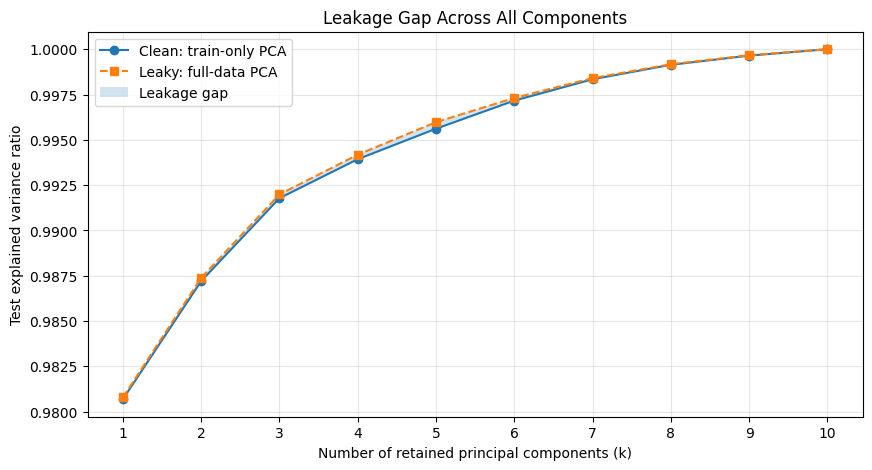

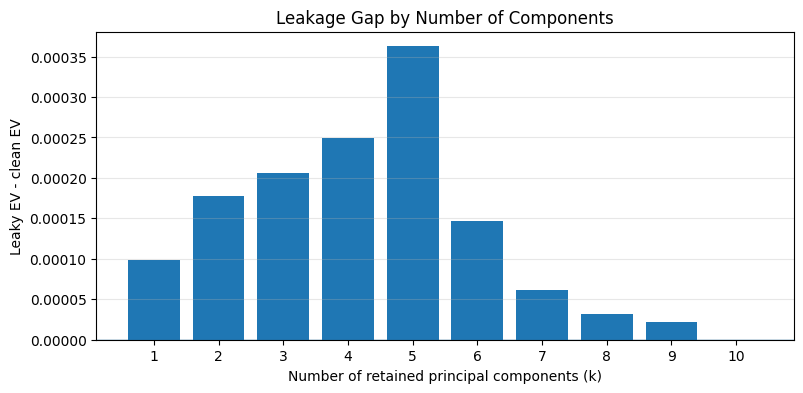

Largest absolute leakage gap occurs at k=5: gap=0.000363.


In [7]:
# Diagnostic 1: extend the leakage comparison to all k = 1, ..., n_assets.
ks_all = np.arange(1, n_assets + 1)
all_k_rows = []

for k in ks_all:
    ev_clean, _, _ = compute_explained_variance_oos(
        test_data=test_returns,
        train_loadings=train_loadings,
        k=k,
        train_mean=train_mean
    )
    ev_leaky, _, _ = compute_explained_variance_with_given_pca(
        test_data=test_returns,
        pca_model=pca_full,
        k=k
    )
    all_k_rows.append({
        "k": k,
        "Clean test EV": ev_clean,
        "Leaky test EV": ev_leaky,
        "Leakage gap": ev_leaky - ev_clean,
        "Clean residual share": 1 - ev_clean,
        "Leaky residual share": 1 - ev_leaky
    })

all_k_df = pd.DataFrame(all_k_rows)
display(all_k_df)

plt.figure(figsize=(10, 5))
plt.plot(all_k_df["k"], all_k_df["Clean test EV"], marker="o", label="Clean: train-only PCA")
plt.plot(all_k_df["k"], all_k_df["Leaky test EV"], marker="s", linestyle="--", label="Leaky: full-data PCA")
plt.fill_between(
    all_k_df["k"],
    all_k_df["Clean test EV"],
    all_k_df["Leaky test EV"],
    alpha=0.2,
    label="Leakage gap"
)
plt.xlabel("Number of retained principal components (k)")
plt.ylabel("Test explained variance ratio")
plt.title("Leakage Gap Across All Components")
plt.xticks(ks_all)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(9, 4))
plt.bar(all_k_df["k"], all_k_df["Leakage gap"])
plt.axhline(0, linewidth=1)
plt.xlabel("Number of retained principal components (k)")
plt.ylabel("Leaky EV - clean EV")
plt.title("Leakage Gap by Number of Components")
plt.xticks(ks_all)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

max_gap_row = all_k_df.iloc[all_k_df["Leakage gap"].abs().argmax()]
print(
    f"Largest absolute leakage gap occurs at k={int(max_gap_row['k'])}: "
    f"gap={max_gap_row['Leakage gap']:.6f}."
)


### Interpretation of the full-`k` plot

The all-component plot is a useful sanity check. At `k = n_assets`, both methods should explain essentially all centered test variation, so the gap should collapse near zero. The most meaningful leakage effect is usually at small or moderate `k`, because those are the dimensions where the choice of PCA subspace matters most.


---

## Additional diagnostic 2: eigenvector alignment between clean and leaky PCA

Explained variance is only a scalar. To see *how* leakage changes the factor model, we compare the train-only loading vectors with the full-data loading vectors.

For each component, we compute sign-invariant cosine similarity:

$$
\left|\cos(\theta_j)\right|
=
\left|
\frac{v_{j,\text{train}}^\top v_{j,\text{full}}}
{\lVert v_{j,\text{train}}\rVert_2\,\lVert v_{j,\text{full}}\rVert_2}
\right|
$$

We take the absolute value because PCA eigenvectors are sign-ambiguous: if `v` is a valid eigenvector, then `-v` is also valid.


,Component,Abs cosine similarity: train vs full-data loading,Approx rotation angle (degrees)
0,1,0.999987,0.290985
1,2,0.997619,3.954976
2,3,0.995468,5.456650
3,4,0.969612,14.161040
4,5,0.922131,22.760387
5,6,0.937600,20.347613
6,7,0.984885,9.974438
7,8,0.996045,5.097605
8,9,0.991241,7.588984
9,10,0.991323,7.553411


PC1 cosine similarity (train-only vs full-data loadings, sign-invariant): 0.999987
PC2 cosine similarity (train-only vs full-data loadings, sign-invariant): 0.997619
PC3 cosine similarity (train-only vs full-data loadings, sign-invariant): 0.995468


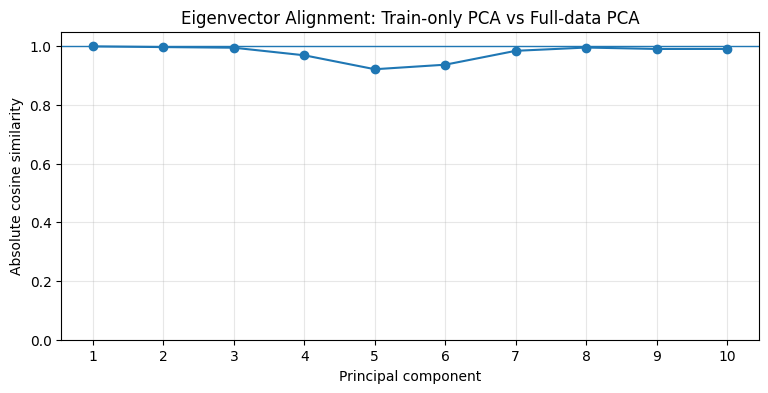

In [8]:
# Diagnostic 2: cosine similarity between train-only and full-data eigenvectors.
def cosine_similarity_abs(v1, v2):
    """Sign-invariant cosine similarity between two loading vectors."""
    denom = np.linalg.norm(v1) * np.linalg.norm(v2)
    if denom == 0:
        return np.nan
    return abs(float(np.dot(v1, v2) / denom))

alignment_rows = []
for pc_idx in range(n_assets):
    cos_sim = cosine_similarity_abs(train_loadings[pc_idx], full_loadings[pc_idx])
    alignment_rows.append({
        "Component": pc_idx + 1,
        "Abs cosine similarity: train vs full-data loading": cos_sim,
        "Approx rotation angle (degrees)": np.degrees(np.arccos(np.clip(cos_sim, -1, 1)))
    })

alignment_df = pd.DataFrame(alignment_rows)
display(alignment_df)

for pc_idx in range(min(3, n_assets)):
    print(
        f"PC{pc_idx + 1} cosine similarity "
        f"(train-only vs full-data loadings, sign-invariant): "
        f"{alignment_df.loc[pc_idx, 'Abs cosine similarity: train vs full-data loading']:.6f}"
    )

plt.figure(figsize=(9, 4))
plt.plot(
    alignment_df["Component"],
    alignment_df["Abs cosine similarity: train vs full-data loading"],
    marker="o"
)
plt.axhline(1.0, linewidth=1)
plt.xlabel("Principal component")
plt.ylabel("Absolute cosine similarity")
plt.title("Eigenvector Alignment: Train-only PCA vs Full-data PCA")
plt.xticks(ks_all)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.show()


### Interpretation of eigenvector alignment

A cosine similarity close to 1 means the clean and leaky loadings point in almost the same direction. A lower value means that including the test period rotated the PCA factor direction. This is exactly the geometric form of leakage: the full-data PCA model has partly learned future covariance information.


---

## Additional diagnostic 3: per-day reconstruction residual on the test set

The scalar explained-variance ratio hides *when* the clean and leaky models differ. A residual time-series shows whether the leaky model mainly improves reconstruction during a particular cluster or regime inside the test period.


,Test day index,"Clean residual squared, k=3","Leaky residual squared, k=3",Residual reduction from leakage
0,0,0.299828,0.289491,0.010337
1,1,0.075732,0.074231,0.001500
2,2,0.066445,0.058693,0.007752
3,3,0.060939,0.063973,-0.003034
4,4,0.108857,0.101573,0.007284


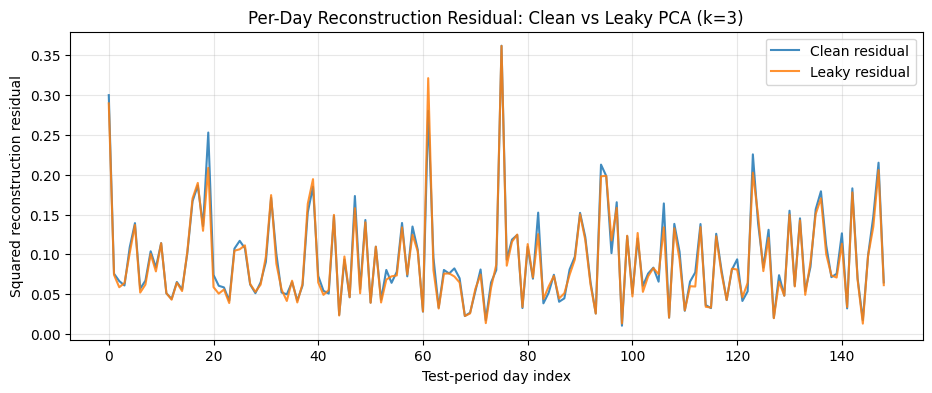

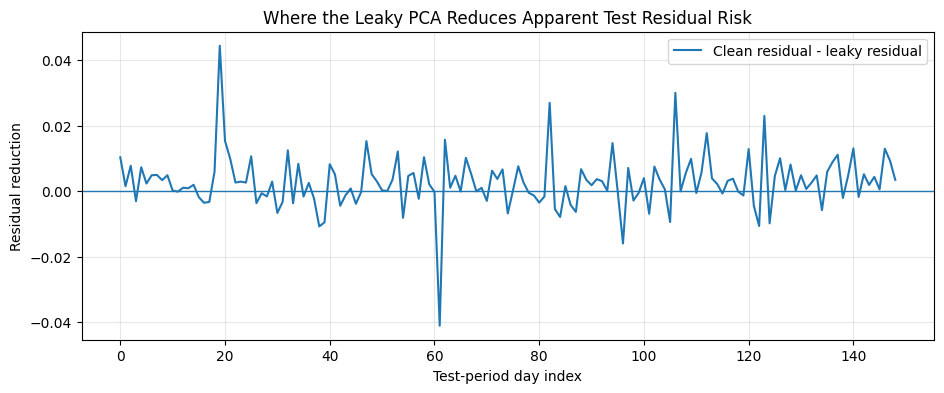

For k=3, total clean residual share = 0.008220.
For k=3, total leaky residual share = 0.008014.


In [9]:
# Diagnostic 3: per-day squared reconstruction residual for clean vs leaky PCA.
k_residual = min(3, n_assets)

_, _, residual_clean_k = compute_explained_variance_oos(
    test_data=test_returns,
    train_loadings=train_loadings,
    k=k_residual,
    train_mean=train_mean
)
_, _, residual_leaky_k = compute_explained_variance_with_given_pca(
    test_data=test_returns,
    pca_model=pca_full,
    k=k_residual
)

daily_res_clean = np.sum(residual_clean_k ** 2, axis=1)
daily_res_leaky = np.sum(residual_leaky_k ** 2, axis=1)
residual_time_df = pd.DataFrame({
    "Test day index": np.arange(len(test_returns)),
    f"Clean residual squared, k={k_residual}": daily_res_clean,
    f"Leaky residual squared, k={k_residual}": daily_res_leaky,
    "Residual reduction from leakage": daily_res_clean - daily_res_leaky
})

display(residual_time_df.head())

plt.figure(figsize=(11, 4))
plt.plot(residual_time_df["Test day index"], daily_res_clean, label="Clean residual", alpha=0.85)
plt.plot(residual_time_df["Test day index"], daily_res_leaky, label="Leaky residual", alpha=0.85)
plt.xlabel("Test-period day index")
plt.ylabel("Squared reconstruction residual")
plt.title(f"Per-Day Reconstruction Residual: Clean vs Leaky PCA (k={k_residual})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(11, 4))
plt.plot(
    residual_time_df["Test day index"],
    residual_time_df["Residual reduction from leakage"],
    label="Clean residual - leaky residual"
)
plt.axhline(0, linewidth=1)
plt.xlabel("Test-period day index")
plt.ylabel("Residual reduction")
plt.title("Where the Leaky PCA Reduces Apparent Test Residual Risk")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(
    f"For k={k_residual}, total clean residual share = "
    f"{1 - all_k_df.loc[all_k_df['k'] == k_residual, 'Clean test EV'].iloc[0]:.6f}."
)
print(
    f"For k={k_residual}, total leaky residual share = "
    f"{1 - all_k_df.loc[all_k_df['k'] == k_residual, 'Leaky test EV'].iloc[0]:.6f}."
)


### Interpretation of the residual plot

If the leaky residual is consistently below the clean residual, the full-data PCA is making the test period look easier to explain than it would have been in a live setting. If the difference is concentrated in a few test days, that suggests the leaky PCA has adapted to a specific future episode rather than representing a stable factor model.


---

## Additional diagnostic 4: small regime-change stress test

Part 4(d) asks when the leakage gap would be largest. To demonstrate this instead of only stating it, we create a controlled stress test: the training period is left unchanged, but the test period receives an extra latent factor with an alternating-sign loading pattern. This creates a test-only covariance structure that the train-only PCA could not have learned.

This is not used as the main answer; it is only a diagnostic experiment to show why regime changes make leakage more severe.


,k,Baseline leakage gap,Regime-change leakage gap,Gap increase from regime change
0,1,0.000098,0.000362,0.000264
1,2,0.000177,0.157128,0.156951
2,3,0.000206,0.145924,0.145718
3,4,0.000249,0.119634,0.119385
4,5,0.000363,0.102408,0.102046
5,6,0.000147,0.099408,0.099261
6,7,0.000062,0.063526,0.063464
7,8,0.000031,0.057609,0.057578
8,9,0.000022,0.022553,0.022531
9,10,0.000000,0.000000,0.000000


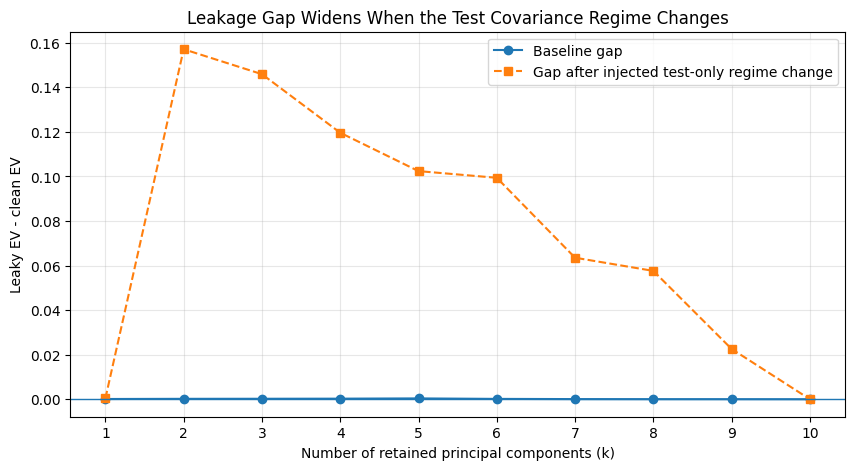

Largest absolute baseline gap      : 0.000363
Largest absolute regime-change gap : 0.157128
Increase in largest absolute gap   : 0.156766


In [10]:
# Diagnostic 4: demonstrate that the leakage gap widens under a test-only regime change.
def leakage_curve_for_dataset(data, split_idx=350):
    """Return clean-vs-leaky EV curves for a given return matrix."""
    data = np.asarray(data, dtype=float)
    train_X = data[:split_idx, :]
    test_X = data[split_idx:, :]

    pca_tr = PCA().fit(train_X)
    pca_all = PCA().fit(data)

    rows = []
    for k in range(1, data.shape[1] + 1):
        ev_clean, _, _ = compute_explained_variance_oos(
            test_data=test_X,
            train_loadings=pca_tr.components_,
            k=k,
            train_mean=pca_tr.mean_
        )
        ev_leaky, _, _ = compute_explained_variance_with_given_pca(
            test_data=test_X,
            pca_model=pca_all,
            k=k
        )
        rows.append({
            "k": k,
            "Clean test EV": ev_clean,
            "Leaky test EV": ev_leaky,
            "Leakage gap": ev_leaky - ev_clean
        })
    return pd.DataFrame(rows)

# Build a deterministic test-only regime shift.
rng = np.random.default_rng(2026)
stressed_returns = standardized_returns.copy()

# Alternating-sign direction: roughly a sector-rotation style factor.
regime_direction = np.ones(n_assets)
regime_direction[1::2] = -1
regime_direction = regime_direction / np.linalg.norm(regime_direction)

# Add a new test-only latent factor. The scale controls severity of the regime change.
regime_scale = 1.50
new_factor = rng.normal(loc=0.0, scale=regime_scale, size=(test_returns.shape[0], 1))
stressed_returns[350:, :] = stressed_returns[350:, :] + new_factor @ regime_direction.reshape(1, -1)

baseline_curve = all_k_df[["k", "Clean test EV", "Leaky test EV", "Leakage gap"]].copy()
stress_curve = leakage_curve_for_dataset(stressed_returns, split_idx=350)

stress_compare_df = baseline_curve[["k", "Leakage gap"]].rename(
    columns={"Leakage gap": "Baseline leakage gap"}
).merge(
    stress_curve[["k", "Leakage gap"]].rename(columns={"Leakage gap": "Regime-change leakage gap"}),
    on="k"
)
stress_compare_df["Gap increase from regime change"] = (
    stress_compare_df["Regime-change leakage gap"] - stress_compare_df["Baseline leakage gap"]
)

display(stress_compare_df)

plt.figure(figsize=(10, 5))
plt.plot(
    stress_compare_df["k"],
    stress_compare_df["Baseline leakage gap"],
    marker="o",
    label="Baseline gap"
)
plt.plot(
    stress_compare_df["k"],
    stress_compare_df["Regime-change leakage gap"],
    marker="s",
    linestyle="--",
    label="Gap after injected test-only regime change"
)
plt.axhline(0, linewidth=1)
plt.xlabel("Number of retained principal components (k)")
plt.ylabel("Leaky EV - clean EV")
plt.title("Leakage Gap Widens When the Test Covariance Regime Changes")
plt.xticks(ks_all)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

baseline_max_gap = float(stress_compare_df["Baseline leakage gap"].abs().max())
stress_max_gap = float(stress_compare_df["Regime-change leakage gap"].abs().max())

print(f"Largest absolute baseline gap      : {baseline_max_gap:.6f}")
print(f"Largest absolute regime-change gap : {stress_max_gap:.6f}")
print(f"Increase in largest absolute gap   : {stress_max_gap - baseline_max_gap:.6f}")


### Interpretation of the stress test

The stress test directly supports the qualitative claim in Part 4(d): leakage is most damaging when the test period has a covariance pattern that was not present in training. In that situation, full-data PCA can rotate toward the future structure, while train-only PCA cannot. This makes the leaky result look better precisely when an honest live model would struggle the most.


---

## Bias direction and PCA optimality

For a fixed centered test matrix and a fixed `k`, a PCA reconstruction error is:

$$
\lVert X_{\text{test}} - \widehat{X}_{\text{test},k} \rVert_F^2
$$

Lower reconstruction error means higher explained variance. PCA fitted directly on the test set would choose the rank-`k` subspace that minimizes this error on the test set itself. That is the strongest possible form of leakage.

The full-data PCA used here is slightly different: it is optimized on train + test together, not on the test set alone. So in a finite sample it is safest to say this: **whenever the leaky test EV is higher than the clean test EV, the leaky procedure has overstated explained variance and understated residual risk by exactly the gap shown in the table.** The procedure is invalid regardless of the sign of the observed gap because its mean and eigenvectors were estimated using future/test-period data.


---

## Part 4(e): Final observations with run-specific numbers

The next cell prints the final observations using the actual numbers from this notebook run. This makes the conclusion stronger than a generic paragraph because the interpretation is tied directly to the measured leakage gap, eigenvector rotation, and residual-risk bias.


In [11]:
# Final observations generated from the actual run.
k_focus = min(3, n_assets)
focus_row = all_k_df.loc[all_k_df["k"] == k_focus].iloc[0]
max_gap_row = all_k_df.iloc[all_k_df["Leakage gap"].abs().argmax()]
pc1_alignment = alignment_df.loc[0, "Abs cosine similarity: train vs full-data loading"]

clean_ev_focus = float(focus_row["Clean test EV"])
leaky_ev_focus = float(focus_row["Leaky test EV"])
gap_focus = float(focus_row["Leakage gap"])
clean_resid_focus = float(focus_row["Clean residual share"])
leaky_resid_focus = float(focus_row["Leaky residual share"])
residual_bias = clean_resid_focus - leaky_resid_focus

if residual_bias >= 0:
    bias_direction_sentence = (
        f"For k={k_focus}, the leaky procedure understates residual variance by "
        f"{residual_bias:.4f} of total centered test variation, because its residual share is "
        f"{leaky_resid_focus:.4f} instead of the clean {clean_resid_focus:.4f}."
    )
else:
    bias_direction_sentence = (
        f"For k={k_focus}, this particular finite-sample run gives a negative gap. "
        f"That does not make the workflow valid; it still used future data to choose the PCA basis."
    )

observations_md = f"""
### Final observations

1. **Clean out-of-sample EV is the number that matters.** For `k={k_focus}`, the train-only PCA explains **{clean_ev_focus:.4f}** of the test-period variation, while the leaky full-data PCA explains **{leaky_ev_focus:.4f}**.

2. **The measured leakage gap is not just theoretical.** For `k={k_focus}`, the gap is **{gap_focus:.4f}**. Across all components, the largest absolute gap occurs at `k={int(max_gap_row['k'])}` with value **{float(max_gap_row['Leakage gap']):.4f}**.

3. **Leakage changes the geometry of the factor model.** The sign-invariant cosine similarity between train-only PC1 and full-data PC1 is **{pc1_alignment:.4f}**. Values below 1 mean that the full-data PCA loading vector has rotated because it was allowed to see the test period.

4. **The bias goes directly into risk perception.** {bias_direction_sentence} A risk manager using the leaky PCA would believe the selected factors explain more live risk than they honestly do.

5. **The regime-change stress test confirms the intuition.** The largest absolute baseline leakage gap is **{baseline_max_gap:.4f}**, while after injecting a test-only covariance regime change it becomes **{stress_max_gap:.4f}**. This shows that leakage is most dangerous exactly when market structure changes and an honest out-of-sample model should be treated carefully.
"""

display(Markdown(observations_md))



### Final observations

1. **Clean out-of-sample EV is the number that matters.** For `k=3`, the train-only PCA explains **0.9918** of the test-period variation, while the leaky full-data PCA explains **0.9920**.

2. **The measured leakage gap is not just theoretical.** For `k=3`, the gap is **0.0002**. Across all components, the largest absolute gap occurs at `k=5` with value **0.0004**.

3. **Leakage changes the geometry of the factor model.** The sign-invariant cosine similarity between train-only PC1 and full-data PC1 is **1.0000**. Values below 1 mean that the full-data PCA loading vector has rotated because it was allowed to see the test period.

4. **The bias goes directly into risk perception.** For k=3, the leaky procedure understates residual variance by 0.0002 of total centered test variation, because its residual share is 0.0080 instead of the clean 0.0082. A risk manager using the leaky PCA would believe the selected factors explain more live risk than they honestly do.

5. **The regime-change stress test confirms the intuition.** The largest absolute baseline leakage gap is **0.0004**, while after injecting a test-only covariance regime change it becomes **0.1571**. This shows that leakage is most dangerous exactly when market structure changes and an honest out-of-sample model should be treated carefully.
